1. Функции потерь и ручной расчёт градиентов.  
Импорты и данные

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Данные для MSE и MAE
y_true_reg = np.array([1.0, 0.0, 2.0])
y_pred_reg = np.array([0.8, 0.4, 1.5])

# Данные для Binary Cross-Entropy
y_true_bce = np.array([1, 0, 1, 0])
y_pred_bce = np.array([0.9, 0.3, 0.6, 0.2])

In [13]:
#MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mse_gradient(y_true, y_pred):
    n = len(y_true)
    return (2 / n) * (y_pred - y_true)


mse_value = mse(y_true_reg, y_pred_reg)
mse_grad = mse_gradient(y_true_reg, y_pred_reg)

print("MSE:", round(mse_value, 4))
print("Градиент MSE:", mse_grad.round(4))

#MAE
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mae_gradient(y_true, y_pred):
    n = len(y_true)

    # np.sign:
    # отрицательное число -> -1
    # 0 -> 0
    # положительное число -> 1
    return np.sign(y_pred - y_true) / n


mae_value = mae(y_true_reg, y_pred_reg)
mae_grad = mae_gradient(y_true_reg, y_pred_reg)

print("MAE:", round(mae_value, 4))
print("Субградиент MAE:", mae_grad.round(4))

#Binary Cross-Entropy
def binary_cross_entropy(y_true, y_pred):
    # Не позволяем вероятностям стать ровно 0 или 1,
    # иначе log(0) даст математическую ошибку
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def bce_gradient(y_true, y_pred):

    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)

    n = len(y_true)

    return (-y_true / y_pred + (1 - y_true) / (1 - y_pred)) / n


bce_value = binary_cross_entropy(y_true_bce, y_pred_bce)
bce_grad = bce_gradient(y_true_bce, y_pred_bce)

print("Binary Cross-Entropy:", round(bce_value, 4))
print("Градиент BCE:", bce_grad.round(4))

MSE: 0.15
Градиент MSE: [-0.1333  0.2667 -0.3333]
MAE: 0.3667
Субградиент MAE: [-0.3333  0.3333 -0.3333]
Binary Cross-Entropy: 0.299
Градиент BCE: [-0.2778  0.3571 -0.4167  0.3125]


In [14]:
loss_results = pd.DataFrame({
    "Loss": [
        mse_value,
        mae_value,
        bce_value],
    "Gradient": [
        mse_grad.round(4),
        mae_grad.round(4),
        bce_grad.round(4)]},
index=["MSE", "MAE", "Binary Cross-Entropy"])

loss_results

,Loss,Gradient
MSE,0.150000,"[-0.1333, 0.2667, -0.3333]"
MAE,0.366667,"[-0.3333, 0.3333, -0.3333]"
Binary Cross-Entropy,0.299001,"[-0.2778, 0.3571, -0.4167, 0.3125]"


MSE сильнее штрафует большие ошибки, поскольку ошибка возводится в квадрат. Поэтому MSE чувствительнее к выбросам, однако поскольку у нас все ошибки меньше 1, возведение в квадрат делает их численно меньше.   

MAE растёт линейно и является более устойчивой к большим отдельным ошибкам, однако её функция негладкая в точке нулевой ошибки.  

Напрямую сравнивать эти значения как качество нельзя, поскольку функции имеют разные шкалы. Главное различие заключается в характере штрафа: MAE увеличивается линейно с ростом абсолютной ошибки, а MSE — квадратично, поэтому крупные ошибки оказывают на MSE относительно большее влияние.

Binary Cross-Entropy естественно подходит для бинарной классификации, поскольку работает с предсказанными вероятностями и особенно сильно штрафует модель за уверенные неправильные предсказания.

2. Градиентный спуск для f(x,y)=x^2+5y^2

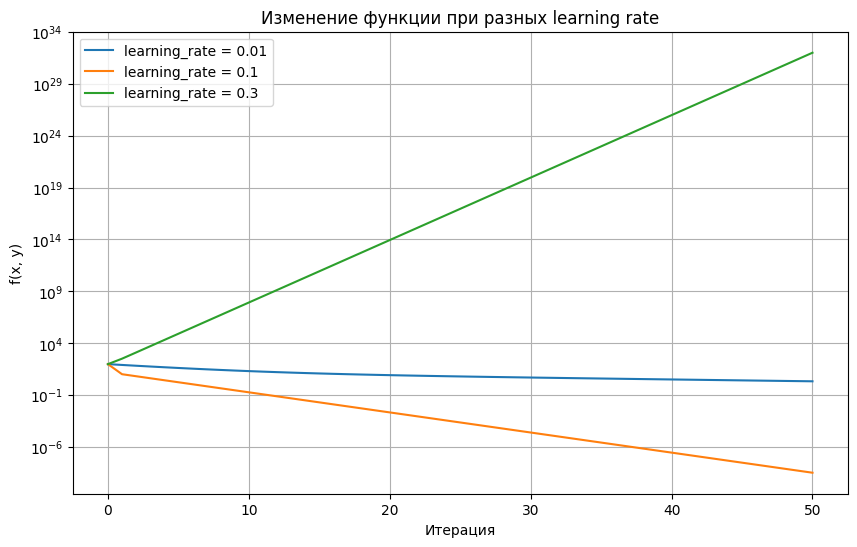

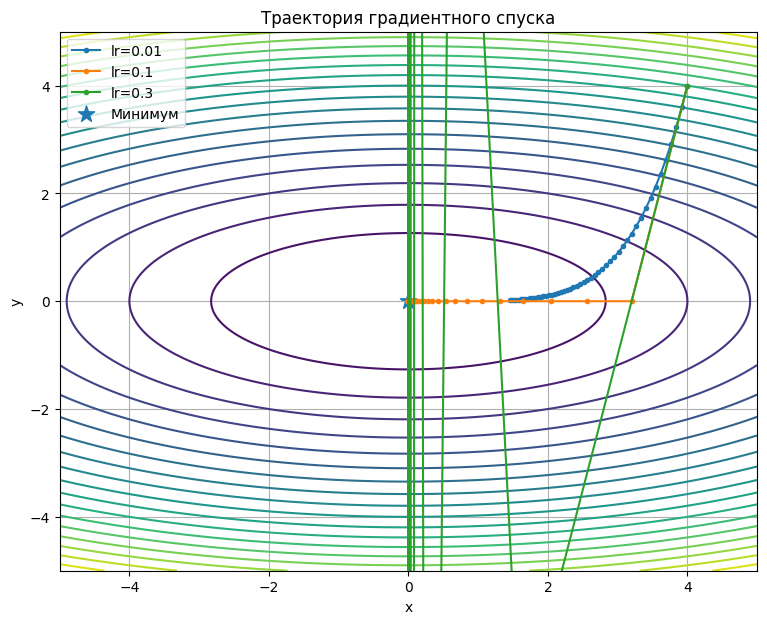

In [15]:
#Функция и градиент
def f(point):
    x, y = point
    return x**2 + 5 * y**2


def grad_f(point):
    x, y = point
    return np.array([2 * x, 10 * y])

#Реализация градиентного спуска
def gradient_descent(start_point, learning_rate, n_iterations=50):

    # Текущая точка
    point = np.array(start_point, dtype=float)

    # Будем сохранять все точки
    trajectory = [point.copy()]

    # Значения функции на каждой итерации
    losses = [f(point)]

    for _ in range(n_iterations):

        # Вычисляем градиент в текущей точке
        gradient = grad_f(point)

        # Делаем шаг в противоположную сторону от градиента
        point = point - learning_rate * gradient

        # Сохраняем новую точку
        trajectory.append(point.copy())

        # Сохраняем новое значение функции
        losses.append(f(point))

    return np.array(trajectory), np.array(losses)

#Запускаем для трёх learning rate
start_point = [4, 4]

learning_rates = [0.01, 0.1, 0.3]

gd_results = {}

for lr in learning_rates:

    trajectory, losses = gradient_descent(
        start_point=start_point,
        learning_rate=lr,
        n_iterations=50)

    gd_results[lr] = {
        "trajectory": trajectory,
        "losses": losses}


#Значение функции по итерациям
plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        gd_results[lr]["losses"],
        label=f"learning_rate = {lr}")

plt.xlabel("Итерация")
plt.ylabel("f(x, y)")
plt.title("Изменение функции при разных learning rate")
plt.legend()
plt.grid()

# Из-за расходимости lr=0.3 удобнее логарифмическая шкала
plt.yscale("log")

plt.show()

#Линии уровня + траектории
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X_grid, Y_grid = np.meshgrid(x, y)

Z = X_grid**2 + 5 * Y_grid**2

plt.figure(figsize=(9, 7))

# Линии одинакового значения функции
plt.contour(
    X_grid,
    Y_grid,
    Z,
    levels=20)

for lr in learning_rates:

    trajectory = gd_results[lr]["trajectory"]

    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        marker="o",
        markersize=3,
        label=f"lr={lr}")

plt.scatter(
    0,
    0,
    marker="*",
    s=150,
    label="Минимум")

plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Траектория градиентного спуска")
plt.legend()
plt.grid()

plt.show()

При learning_rate=0.01 алгоритм устойчиво, но сравнительно медленно движется к минимуму.   
При learning_rate=0.1 сходимость существенно быстрее.   
При learning_rate=0.3 шаг становится слишком большим, и алгоритм расходится. Таким образом, слишком маленький learning rate замедляет обучение, а слишком большой может сделать градиентный спуск нестабильным.

3. Полный Gradient Descent против SGD на линейной регрессии

In [16]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = make_regression(
    n_samples=300,
    n_features=1,
    noise=15,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

#Чтобы добавить свободный коэффициент b, добавим столбец единиц
X_train_bias = np.c_[np.ones(len(X_train)), X_train]
X_test_bias = np.c_[np.ones(len(X_test)), X_test]

#Теперь:y=w0+w1*x  где w0 — intercept, а w1 — коэффициент перед x.

#Полный Gradient Descent.При полном GD на каждом шаге градиент рассчитывается по всей train-выборке.
def full_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    n_epochs=100):

    n_samples, n_features = X.shape

    # Начальные веса = 0
    weights = np.zeros(n_features)

    losses = []

    for epoch in range(n_epochs):

        # Предсказания на всей выборке
        y_pred = X @ weights

        # Ошки
        error = y_pred - y

        # MSE
        loss = np.mean(error**2)
        losses.append(loss)

        # Градиент MSE по всем объектам сразу
        gradient = (2 / n_samples) * X.T @ error

        # Обновляем веса
        weights -= learning_rate * gradient

    return weights, losses

#SGD. В SGD веса обновляются после каждого отдельного объекта.
def stochastic_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    n_epochs=100,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    n_samples, n_features = X.shape

    weights = np.zeros(n_features)

    losses = []

    for epoch in range(n_epochs):

        # Перемешиваем объекты перед каждой эпохой
        indices = rng.permutation(n_samples)

        for i in indices:

            xi = X[i]
            yi = y[i]

            # Предсказание одного объекта
            y_pred = xi @ weights

            error = y_pred - yi

            # Градиент по одному объекту
            gradient = 2 * xi * error

            # Сразу обновляем веса
            weights -= learning_rate * gradient

        # После эпохи считаем loss по всей train-выборке
        epoch_pred = X @ weights
        loss = np.mean((epoch_pred - y) ** 2)

        losses.append(loss)

    return weights, losses

In [17]:
#Запускаем
weights_gd, losses_gd = full_gradient_descent(
    X_train_bias,
    y_train,
    learning_rate=0.01,
    n_epochs=100)

weights_sgd, losses_sgd = stochastic_gradient_descent(
    X_train_bias,
    y_train,
    learning_rate=0.001,
    n_epochs=100)

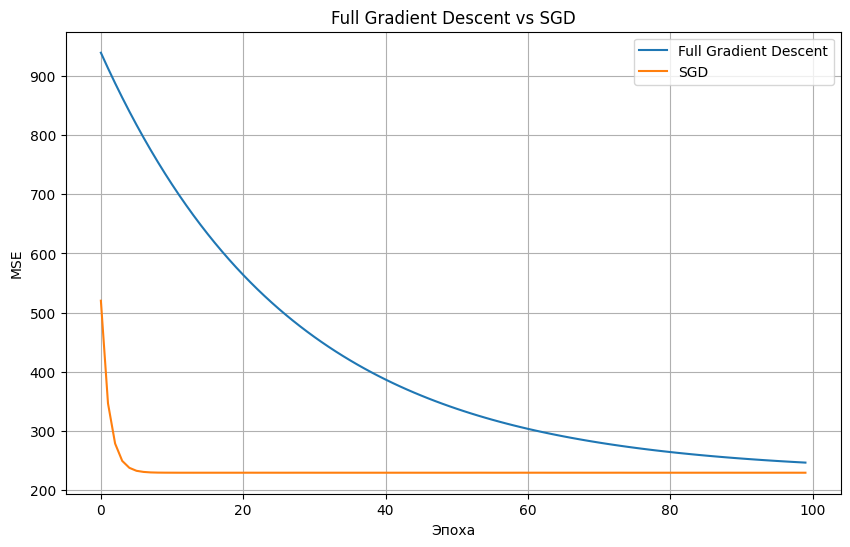

In [18]:
#Сравнение Loss
plt.figure(figsize=(10, 6))

plt.plot(losses_gd, label="Full Gradient Descent")
plt.plot(losses_sgd, label="SGD")

plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Full Gradient Descent vs SGD")
plt.legend()
plt.grid()

plt.show()

In [19]:
#Проверяем качество на тесте
y_pred_gd = X_test_bias @ weights_gd
y_pred_sgd = X_test_bias @ weights_sgd

mse_gd_test = mean_squared_error(y_test, y_pred_gd)
mse_sgd_test = mean_squared_error(y_test, y_pred_sgd)

comparison_regression = pd.DataFrame({
    "Test MSE": [
        mse_gd_test,
        mse_sgd_test]},
index=[
    "Full Gradient Descent",
    "SGD"])

comparison_regression.round(3)

,Test MSE
Full Gradient Descent,276.878
SGD,239.837


В данном эксперименте SGD значительно быстрее уменьшил функцию потерь и уже за несколько эпох приблизился к минимуму, тогда как полный Gradient Descent сходился существенно медленнее. На тестовой выборке SGD также показал меньший MSE.   
Теоретически SGD обладает более шумными обновлениями, поскольку рассчитывает градиент по отдельным объектам, однако на данном графике loss фиксируется только после завершения каждой эпохи, поэтому эти колебания практически не видны.

4. SGD против Adam для бинарной классификации

In [20]:
#Загружаем Breast Cancer
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import time

data = load_breast_cancer()

X = data.data
y = data.target

#Делим данные
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

#Масштабируем
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Добавляем bias
X_train_scaled = np.c_[
    np.ones(len(X_train_scaled)),
    X_train_scaled]

X_test_scaled = np.c_[
    np.ones(len(X_test_scaled)),
    X_test_scaled]

#Sigmoid
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def logistic_loss(y_true, y_prob):
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)

    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

Logistic Regression + SGD

Здесь используем mini-batch SGD.

In [21]:
def logistic_regression_sgd(
    X,
    y,
    learning_rate=0.01,
    n_epochs=200,
    batch_size=32,
    random_state=42):

    rng = np.random.default_rng(random_state)

    n_samples, n_features = X.shape

    weights = np.zeros(n_features)

    losses = []

    for epoch in range(n_epochs):

        # Перемешиваем объекты
        indices = rng.permutation(n_samples)

        for start in range(0, n_samples, batch_size):

            batch_idx = indices[start:start + batch_size]

            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            # Вероятности класса 1
            probabilities = sigmoid(X_batch @ weights)

            # Градиент BCE для Logistic Regression
            gradient = (X_batch.T @ (probabilities - y_batch)/ len(y_batch))

            # SGD update
            weights -= learning_rate * gradient

        # Loss после всей эпохи
        train_prob = sigmoid(X @ weights)

        losses.append(
            logistic_loss(y, train_prob))

    return weights, losses

Adam хранит две дополнительные величины:

m — сглаженное среднее градиента;
v — сглаженное среднее квадрата градиента.

In [22]:
def logistic_regression_adam(
    X,
    y,
    learning_rate=0.001,
    n_epochs=200,
    batch_size=32,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    random_state=42):

    rng = np.random.default_rng(random_state)

    n_samples, n_features = X.shape

    weights = np.zeros(n_features)

    # Первый момент
    m = np.zeros(n_features)

    # Второй момент
    v = np.zeros(n_features)

    losses = []

    # Счётчик обновлений
    t = 0

    for epoch in range(n_epochs):

        indices = rng.permutation(n_samples)

        for start in range(0, n_samples, batch_size):

            batch_idx = indices[start:start + batch_size]

            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            probabilities = sigmoid(X_batch @ weights)

            gradient = (X_batch.T @ (probabilities - y_batch)/ len(y_batch))

            t += 1

            # Экспоненциальное среднее градиента
            m = beta1 * m + (1 - beta1) * gradient

            # Экспоненциальное среднее квадрата градиента
            v = beta2 * v + (1 - beta2) * (gradient ** 2)

            # Коррекция смещения
            m_hat = m / (1 - beta1 ** t)
            v_hat = v / (1 - beta2 ** t)

            # Обновление Adam
            weights -= (learning_rate* m_hat/(np.sqrt(v_hat) + epsilon))

        train_prob = sigmoid(X @ weights)

        losses.append(
            logistic_loss(y, train_prob))

    return weights, losses

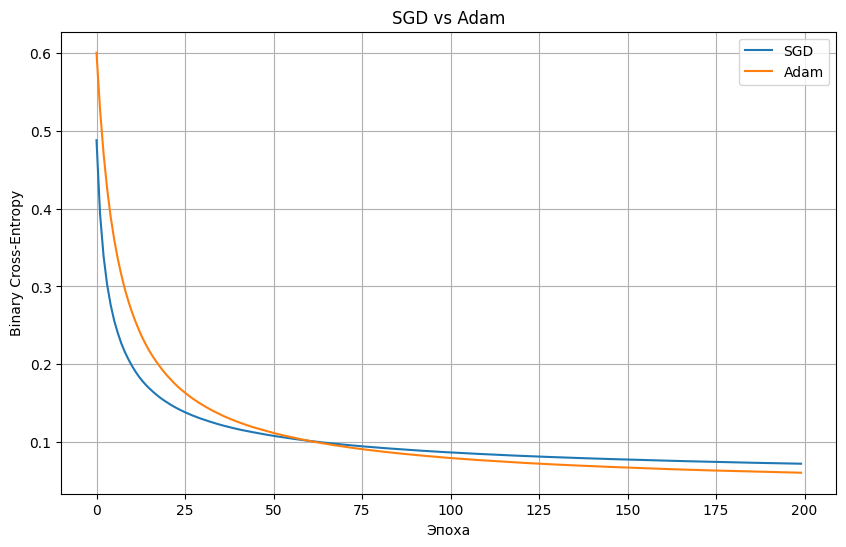

,Accuracy,ROC-AUC,Final Train Loss,"Время, сек."
SGD,0.974,0.996,0.072,0.081
Adam,0.974,0.996,0.061,0.089


In [23]:
#Обучение и замер времени
start = time.perf_counter()

weights_sgd, losses_sgd_class = logistic_regression_sgd(
    X_train_scaled,
    y_train)

sgd_time = time.perf_counter() - start

#Adam
start = time.perf_counter()

weights_adam, losses_adam = logistic_regression_adam(
    X_train_scaled,
    y_train)

adam_time = time.perf_counter() - start

#Loss по эпохам
plt.figure(figsize=(10, 6))

plt.plot(
    losses_sgd_class,
    label="SGD")

plt.plot(
    losses_adam,
    label="Adam")

plt.xlabel("Эпоха")
plt.ylabel("Binary Cross-Entropy")
plt.title("SGD vs Adam")
plt.legend()
plt.grid()

plt.show()

#Test-метрики
# SGD
proba_sgd = sigmoid(
    X_test_scaled @ weights_sgd)

pred_sgd = (proba_sgd >= 0.5).astype(int)


# Adam
proba_adam = sigmoid(
    X_test_scaled @ weights_adam)

pred_adam = (proba_adam >= 0.5).astype(int)

#Таблица
optimizer_comparison = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_test, pred_sgd),
        accuracy_score(y_test, pred_adam)],

    "ROC-AUC": [
        roc_auc_score(y_test, proba_sgd),
        roc_auc_score(y_test, proba_adam)],

    "Final Train Loss": [
        losses_sgd_class[-1],
        losses_adam[-1]],

    "Время, сек.": [
        sgd_time,
        adam_time]},
index=[
    "SGD",
    "Adam"])

optimizer_comparison.round(3)

В задаче бинарной классификации SGD и Adam показали одинаковое качество на тестовой выборке: Accuracy = 0.974 и ROC-AUC = 0.996. При этом SGD быстрее уменьшал loss на первых эпохах и немного быстрее обучился по времени, однако Adam в дальнейшем достиг меньшего итогового значения train loss: 0.061 против 0.072.   
Таким образом, в данном эксперименте Adam не дал прироста тестового качества, но позволил сильнее минимизировать функцию потерь.

Маленький датасет без сильного шума. Можно использовать полный Gradient Descent: вычисление точного градиента на небольшой выборке относительно недорого, а обучение получается предсказуемым и стабильным. При этом в нашем эксперименте SGD сходился заметно быстрее, поэтому выбор полного GD здесь обусловлен скорее простотой и стабильностью, а не более высоким качеством.

Большой датасет с шумными наблюдениями. Предпочтительнее SGD или mini-batch SGD, поскольку для одного обновления не требуется вычислять градиент по всему датасету. Это делает его значительно более масштабируемым.

Нестабильное обучение, где требуется адаптивно управлять шагом. Предпочтителен Adam, поскольку он учитывает историю градиентов и автоматически масштабирует обновления отдельных параметров. В нашем эксперименте Adam достиг меньшего итогового train loss, хотя SGD сходился быстрее на первых эпохах и итоговое тестовое качество обоих оптимизаторов оказалось одинаковым.